### Pergunta Norteadora (O Problema Central)
> **"Como a eficiência logística impacta o faturamento dos e-commerces brasileiros"**



# Atrasos nas entregas


*   **Subpergunta: Qual o impacto do atraso na percepção do cliente?**
    *   **Insight:** O atraso é o principal detrator de marca. A nota média (`review_score`) cai de **4.28** (No Prazo) para **2.26** (Com Atraso), uma redução de quase 50% na satisfação.
*   **Subpergunta: Qual o valor financeiro comprometido por essa insatisfação?**
    *   **Insight:** Identificamos um **Volume de Receita em Risco de R\$ 723.718,60** (pedidos atrasados com notas baixas).



In [64]:
import numpy as np
import pandas as pd

# 1. Carregando as tabelas principais
orders = pd.read_csv("database/olist_orders_dataset.csv")
payments = pd.read_csv("database/olist_order_payments_dataset.csv")
reviews = pd.read_csv("database/olist_order_reviews_dataset.csv")
items = pd.read_csv("database/olist_order_items_dataset.csv")

# 2. Convertendo colunas de data
colunas_data = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]
for col in colunas_data:
    if col in orders.columns:
        orders[col] = pd.to_datetime(orders[col], errors="coerce")

# 3. Agregando pagamentos por pedido (evita duplicar pedidos com múltiplos pagamentos)
pagamentos_pedido = payments.groupby("order_id", as_index=False).agg(
    payment_value=("payment_value", "sum"),
    payment_installments=("payment_installments", "max"),
)

# 4. Deduplicando avaliações: mantém a mais recente por pedido
if "review_answer_timestamp" in reviews.columns:
    reviews["review_answer_timestamp"] = pd.to_datetime(
        reviews["review_answer_timestamp"], errors="coerce"
    )
reviews_pedido = reviews.sort_values(
    ["order_id", "review_answer_timestamp"]
).drop_duplicates("order_id", keep="last")[["order_id", "review_score"]]

# 5. Carregando clientes
customers = pd.read_csv("database/olist_customers_dataset.csv")

# 6. Construindo df_pedidos: uma linha por pedido, com validate para garantir granularidade
df_pedidos = (
    orders.merge(pagamentos_pedido, on="order_id", how="left", validate="one_to_one")
    .merge(reviews_pedido, on="order_id", how="left", validate="one_to_one")
    .merge(
        customers[
            [
                "customer_id",
                "customer_unique_id",
                "customer_zip_code_prefix",
                "customer_state",
            ]
        ],
        on="customer_id",
        how="left",
        validate="many_to_one",
    )
)

# Verificação obrigatória de granularidade
if df_pedidos["order_id"].duplicated().any():
    raise ValueError("df_pedidos possui order_id duplicado.")

print(f"Total de registros na base unificada: {df_pedidos.shape}")
df_pedidos[["order_id", "order_status", "payment_value", "review_score"]].head()

Total de registros na base unificada: (99441, 14)


,order_id,order_status,payment_value,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,38.71,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,141.46,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,179.12,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,72.20,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,28.62,5.0


In [65]:
# 1. Filtrando somente pedidos com status 'delivered' e datas válidas
df_entregues = df_pedidos[
    df_pedidos["order_status"].eq("delivered")
    & df_pedidos["order_delivered_customer_date"].notna()
    & df_pedidos["order_estimated_delivery_date"].notna()
].copy()

# 2. Calculando o atraso em dias de calendário (normalize remove a parte horária,
#    evitando que entregar horas depois no mesmo dia conte como 1 dia de atraso)
df_entregues["dias_atraso"] = (
    df_entregues["order_delivered_customer_date"].dt.normalize()
    - df_entregues["order_estimated_delivery_date"].dt.normalize()
).dt.days

# 3. Coluna binária de atraso
df_entregues["foi_atraso"] = df_entregues["dias_atraso"] > 0

# 4. Flag de receita em risco: pedido atrasado com nota <= 2
df_entregues["receita_em_risco_flag"] = df_entregues["foi_atraso"] & (
    df_entregues["review_score"] <= 2
)

# 5. Coluna de status para os gráficos
df_entregues["status_entrega"] = np.where(
    df_entregues["foi_atraso"], "Com atraso", "No prazo"
)

pedidos_atrasados = int(df_entregues["foi_atraso"].sum())
receita_em_risco = df_entregues.loc[
    df_entregues["receita_em_risco_flag"], "payment_value"
].sum()

print("Estatísticas rápidas do atraso:")
print(df_entregues["dias_atraso"].describe())
print(f"\nPedidos atrasados : {pedidos_atrasados:,}")
print(f"Receita em risco  : R$ {receita_em_risco:,.2f}")

df_entregues[["order_id", "dias_atraso", "foi_atraso", "review_score"]].head()

Estatísticas rápidas do atraso:
count    96470.000000
mean       -11.875889
std         10.182105
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: dias_atraso, dtype: float64

Pedidos atrasados : 6,534
Receita em risco  : R$ 720,919.84


,order_id,dias_atraso,foi_atraso,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,-8,False,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,-6,False,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,-18,False,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,-13,False,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,-10,False,5.0


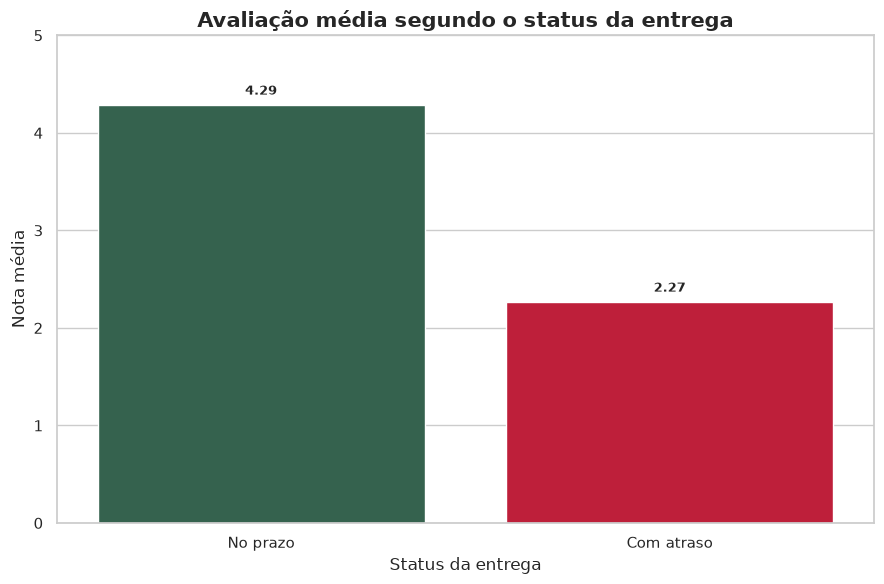

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculando as variáveis necessárias para o gráfico
satisfacao = (
    df_entregues.dropna(subset=["review_score"])
    .groupby("status_entrega")
    .agg(
        pedidos=("order_id", "nunique"),
        nota_media=("review_score", "mean"),
        nota_mediana=("review_score", "median"),
        desvio_padrao=("review_score", "std"),
        percentual_notas_baixas=("review_score", lambda x: (x <= 2).mean() * 100),
    )
    .reset_index()
)

ordem_status = {"No prazo": 0, "Com atraso": 1}
satisfacao["ordem"] = satisfacao["status_entrega"].map(ordem_status)
satisfacao = satisfacao.sort_values("ordem")

# Gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 6))
ax = sns.barplot(
    data=satisfacao,
    x="status_entrega",
    y="nota_media",
    hue="status_entrega",
    palette={"No prazo": "#2D6A4F", "Com atraso": "#D90429"},
    legend=False,
)

ax.set_title(
    "Avaliação média segundo o status da entrega", fontsize=15, fontweight="bold"
)
ax.set_xlabel("Status da entrega")
ax.set_ylabel("Nota média")
ax.set_ylim(0, 5)

for barra in ax.patches:
    altura = barra.get_height()
    if pd.notna(altura):
        ax.annotate(
            f"{altura:.2f}",
            (barra.get_x() + barra.get_width() / 2, altura),
            ha="center",
            va="bottom",
            xytext=(0, 5),
            textcoords="offset points",
            fontsize=9,
            fontweight="bold",
        )

plt.tight_layout()
plt.show()

*   **Subpergunta: Onde e quais estados trazem o maior prejuízo absoluto e relativo?**
    *   **Volume:** **SP e RJ** somam 59% do risco total.


In [67]:
# Agrupando a Receita em Risco por Estado (UF) direto da base de pedidos
# (sem junção com itens, que multiplicaria o valor por linha de produto)
risco_estado = (
    df_entregues[df_entregues["receita_em_risco_flag"]]
    .groupby("customer_state", as_index=False)
    .agg(
        receita_em_risco=("payment_value", "sum"),
        pedidos_em_risco=("order_id", "nunique"),
    )
    .sort_values("receita_em_risco", ascending=False)
)

print("Top 5 Estados com maior Receita em Risco:")
print(risco_estado.head())

Top 5 Estados com maior Receita em Risco:
   customer_state  receita_em_risco  pedidos_em_risco
24             SP         178864.28               971
17             RJ         177932.98              1064
9              MG          52820.89               298
3              BA          46939.07               231
21             RS          34288.34               206


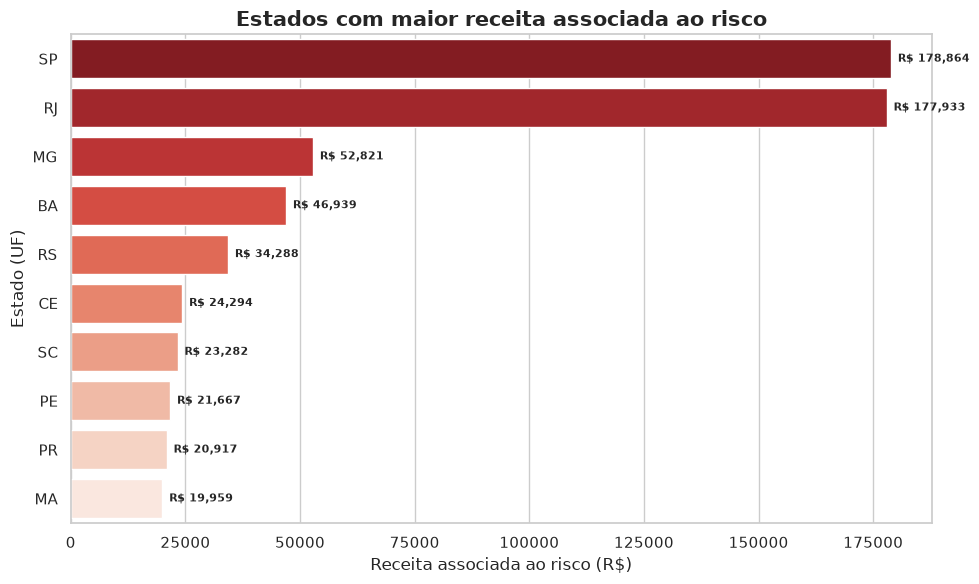

In [68]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=risco_estado.head(10),
    x="receita_em_risco",
    y="customer_state",
    hue="customer_state",
    palette="Reds_r",
    legend=False,
)

ax.set_title(
    "Estados com maior receita associada ao risco",
    fontsize=15,
    fontweight="bold",
)
ax.set_xlabel("Receita associada ao risco (R$)", fontsize=12)
ax.set_ylabel("Estado (UF)", fontsize=12)

for barra in ax.patches:
    valor = barra.get_width()
    ax.annotate(
        f"R$ {valor:,.0f}",
        (valor, barra.get_y() + barra.get_height() / 2),
        ha="left",
        va="center",
        xytext=(5, 0),
        textcoords="offset points",
        fontsize=8,
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

*   **Subpergunta: Onde está o gargalo real do tempo de entrega?**
    *   **Insight:** O problema é logístico e não operacional do vendedor. O tempo médio com a **transportadora é de 27.1 dias**, enquanto o vendedor posta em apenas 5.2 dias.


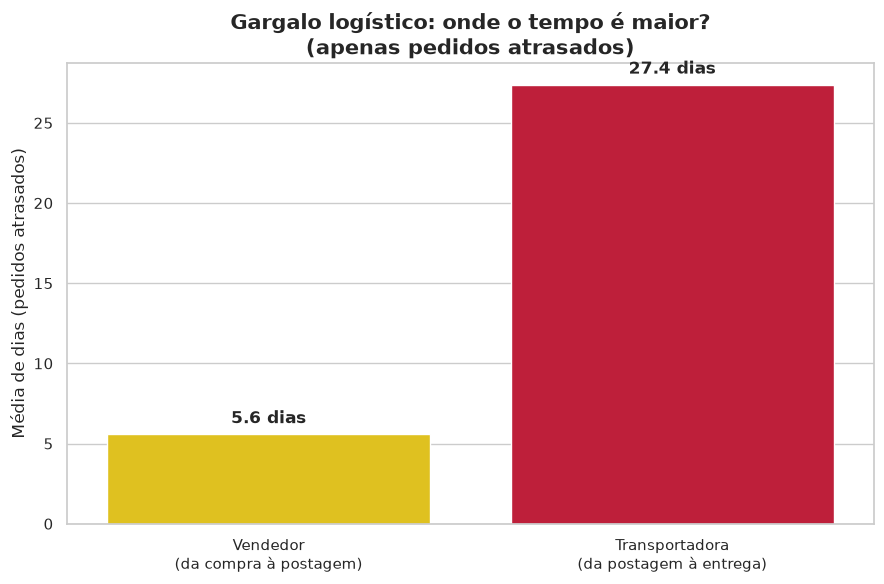

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculando o tempo em cada etapa nos pedidos atrasados
df_entregues["tempo_postagem"] = (
    df_entregues["order_delivered_carrier_date"]
    - df_entregues["order_purchase_timestamp"]
).dt.days

df_entregues["tempo_transporte_etapa"] = (
    df_entregues["order_delivered_customer_date"]
    - df_entregues["order_delivered_carrier_date"]
).dt.days

df_gargalo = df_entregues[df_entregues["foi_atraso"]].dropna(
    subset=["tempo_postagem", "tempo_transporte_etapa"]
)

tempo_medio_postagem = df_gargalo["tempo_postagem"].mean()
tempo_medio_transporte = df_gargalo["tempo_transporte_etapa"].mean()

dados_gargalo = pd.DataFrame(
    {
        "Etapa": [
            "Vendedor\n(da compra à postagem)",
            "Transportadora\n(da postagem à entrega)",
        ],
        "Média de dias": [tempo_medio_postagem, tempo_medio_transporte],
    }
)

plt.figure(figsize=(9, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=dados_gargalo,
    x="Etapa",
    y="Média de dias",
    hue="Etapa",
    palette=["#FFD700", "#D90429"],
    legend=False,
)

ax.set_title(
    "Gargalo logístico: onde o tempo é maior?\n(apenas pedidos atrasados)",
    fontsize=15,
    fontweight="bold",
)
ax.set_ylabel("Média de dias (pedidos atrasados)")
ax.set_xlabel("")

for barra in ax.patches:
    altura = barra.get_height()
    if pd.notna(altura):
        ax.annotate(
            f"{altura:.1f} dias",
            (barra.get_x() + barra.get_width() / 2, altura),
            ha="center",
            va="bottom",
            xytext=(0, 5),
            textcoords="offset points",
            fontweight="bold",
        )

plt.tight_layout()
plt.show()

*   **Subpergunta: Existe um padrão temporal para esse risco?**
    *   **Insight:** O risco não é constante; ele explode durante a **Black Friday e festas de fim de ano** (Nov/2017 a Fev/2018), revelando falta de escalabilidade logística.



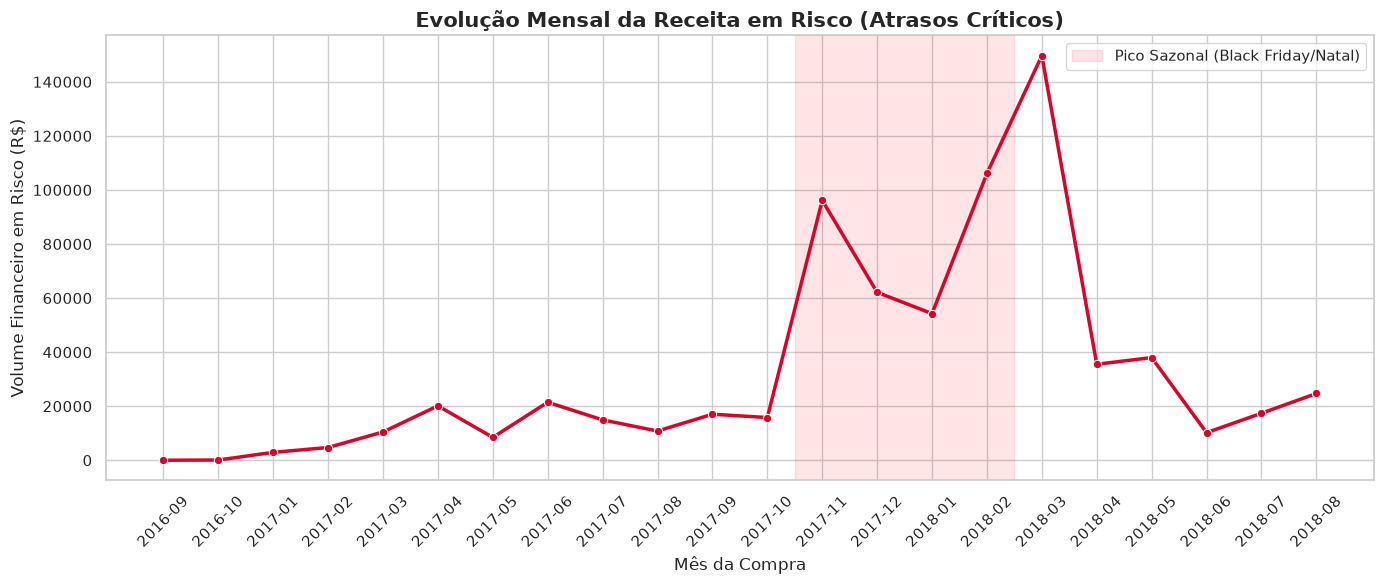

In [70]:
# Calculando a evolução mensal da receita em risco
df_entregues["mes_compra"] = (
    df_entregues["order_purchase_timestamp"].dt.to_period("M").astype(str)
)

risco_mensal = (
    df_entregues[df_entregues["receita_em_risco_flag"]]
    .groupby("mes_compra", as_index=False)
    .agg(
        receita_em_risco=("payment_value", "sum"),
        pedidos_em_risco=("order_id", "nunique"),
    )
    .sort_values("mes_compra")
)

plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")

ax = sns.lineplot(
    data=risco_mensal,
    x="mes_compra",
    y="receita_em_risco",
    marker="o",
    color="#D90429",
    linewidth=2.5,
)

ax.set_title(
    "Evolução Mensal da Receita em Risco (Atrasos Críticos)",
    fontsize=15,
    fontweight="bold",
)
ax.set_xlabel("Mês da Compra")
ax.set_ylabel("Volume Financeiro em Risco (R$)")
plt.xticks(rotation=45)

# Destacando o pico sazonal (nov/2017 a fev/2018)
meses = risco_mensal["mes_compra"].tolist()
if "2017-11" in meses and "2018-02" in meses:
    x_ini = meses.index("2017-11") - 0.5
    x_fim = meses.index("2018-02") + 0.5
    ax.axvspan(
        x_ini,
        x_fim,
        color="red",
        alpha=0.1,
        label="Pico Sazonal (Black Friday/Natal)",
    )
    ax.legend()

plt.tight_layout()
plt.show()

* **Subpergunta:** A distância física entre o vendedor e o comprador é o fator determinante para os atrasos nas entregas?
  * **Insight:** Não. A análise estatística revelou uma correlação de -0.08 entre a distância e o atraso — classificada como quase nula. O atraso crítico é um problema de gestão da malha logística, não de quilometragem percorrida.
  * **Evidência dos dados:** Embora o tempo de transporte suba de 7 para 20,5 dias em rotas longas, a taxa de atraso salta de 4,5% (até 250 km) para 11,7% (acima de 2.000 km). Esse aumento de 150% no risco em rotas longas derruba a satisfação do cliente de 4,21 para 3,92, evidenciando que a malha de longa distância carece de previsibilidade operacional.

In [71]:
import numpy as np
import pandas as pd

# Carregando geolocalização e sellers
geo = pd.read_csv("database/olist_geolocation_dataset.csv")
sellers = pd.read_csv("database/olist_sellers_dataset.csv")

geo_reduzido = (
    geo.groupby("geolocation_zip_code_prefix")[["geolocation_lat", "geolocation_lng"]]
    .mean()
    .reset_index()
)

# Um vendedor por pedido: primeiro seller_id listado nos itens do pedido
seller_por_pedido = items.groupby("order_id")["seller_id"].first().reset_index()

# Base da análise: df_entregues + seller_id + coordenadas
df_distancia = (
    df_entregues[
        [
            "order_id",
            "customer_zip_code_prefix",
            "foi_atraso",
            "dias_atraso",
            "tempo_transporte_etapa",
        ]
    ]
    .merge(seller_por_pedido, on="order_id", how="left")
    .merge(sellers[["seller_id", "seller_zip_code_prefix"]], on="seller_id", how="left")
    .merge(
        geo_reduzido.rename(
            columns={
                "geolocation_zip_code_prefix": "customer_zip_code_prefix",
                "geolocation_lat": "lat_cust",
                "geolocation_lng": "lng_cust",
            }
        ),
        on="customer_zip_code_prefix",
        how="left",
    )
    .merge(
        geo_reduzido.rename(
            columns={
                "geolocation_zip_code_prefix": "seller_zip_code_prefix",
                "geolocation_lat": "lat_seller",
                "geolocation_lng": "lng_seller",
            }
        ),
        on="seller_zip_code_prefix",
        how="left",
    )
    .dropna(subset=["lat_cust", "lng_cust", "lat_seller", "lng_seller"])
)

print(
    f"Pedidos excluídos (sem geolocalização): {len(df_entregues) - len(df_distancia):,}"
)


def haversine(lat1, lon1, lat2, lon2):
    """Distância em km entre dois pontos geográficos (fórmula de Haversine)."""
    r = 6371
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    delta_phi = np.radians(lat2 - lat1)
    delta_lambda = np.radians(lon2 - lon1)
    a = (
        np.sin(delta_phi / 2) ** 2
        + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda / 2) ** 2
    )
    return r * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))


df_distancia["distancia_km"] = haversine(
    df_distancia["lat_cust"],
    df_distancia["lng_cust"],
    df_distancia["lat_seller"],
    df_distancia["lng_seller"],
)

correlacao_distancia = df_distancia["distancia_km"].corr(df_distancia["dias_atraso"])
print(f"Correlação entre Distância e Atraso: {correlacao_distancia:.2f}")

max_dist = df_distancia["distancia_km"].max()
bins_dist = [0, 250, 500, 1000, 2000, max(max_dist + 1, 2001)]
labels_dist = ["Até 250km", "250–500km", "500–1000km", "1000–2000km", "Acima 2000km"]

df_distancia["faixa_distancia"] = pd.cut(
    df_distancia["distancia_km"],
    bins=bins_dist,
    labels=labels_dist,
    right=True,
    include_lowest=True,
)

analise_distancia = (
    df_distancia.groupby("faixa_distancia", observed=False)
    .agg(
        taxa_atraso=("foi_atraso", "mean"),
        tempo_transporte_medio=("tempo_transporte_etapa", "mean"),
        pedidos=("order_id", "nunique"),
    )
    .reset_index()
)
analise_distancia["taxa_atraso_pct"] = analise_distancia["taxa_atraso"] * 100

print("\nImpacto da Distância na Performance Logística:")
print(analise_distancia)

Pedidos excluídos (sem geolocalização): 478
Correlação entre Distância e Atraso: -0.07

Impacto da Distância na Performance Logística:
  faixa_distancia  taxa_atraso  tempo_transporte_medio  pedidos  \
0       Até 250km     0.045942                3.897234    27295   
1       250–500km     0.065188                8.595101    27597   
2      500–1000km     0.071010               10.586707    25743   
3     1000–2000km     0.095546               14.172619     9744   
4    Acima 2000km     0.120791               17.282202     5613   

   taxa_atraso_pct  
0         4.594248  
1         6.518825  
2         7.100959  
3         9.554598  
4        12.079102  


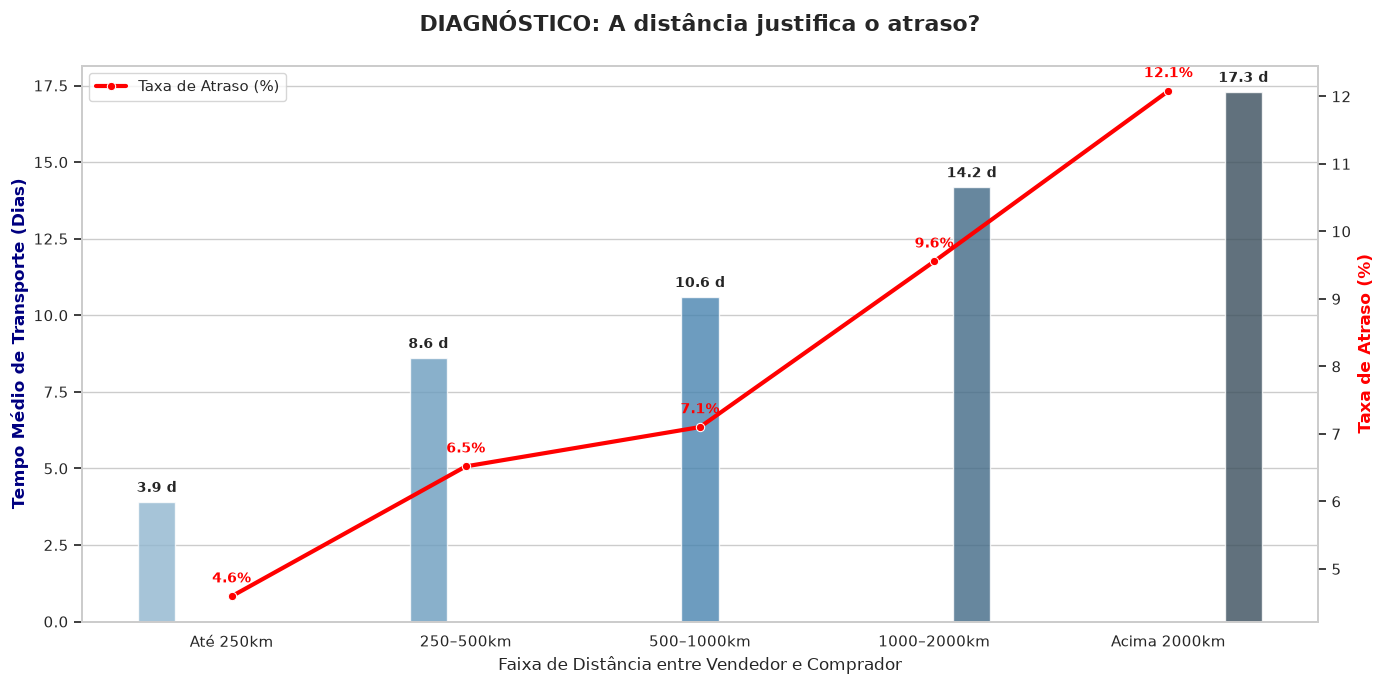

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

fig_dist, ax1_dist = plt.subplots(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# Barras: Tempo médio de transporte (Eixo Y1)
barras_dist = sns.barplot(
    data=analise_distancia,
    x="faixa_distancia",
    y="tempo_transporte_medio",
    ax=ax1_dist,
    hue="faixa_distancia",
    palette="Blues_d",
    alpha=0.8,
    legend=False,
)
ax1_dist.set_ylabel(
    "Tempo Médio de Transporte (Dias)", fontsize=12, fontweight="bold", color="navy"
)
ax1_dist.set_xlabel("Faixa de Distância entre Vendedor e Comprador", fontsize=12)

# Linha: Taxa de Atraso (Eixo Y2)
ax2_dist = ax1_dist.twinx()
sns.lineplot(
    data=analise_distancia,
    x="faixa_distancia",
    y="taxa_atraso_pct",
    ax=ax2_dist,
    marker="o",
    color="red",
    linewidth=3,
    label="Taxa de Atraso (%)",
)
ax2_dist.set_ylabel("Taxa de Atraso (%)", fontsize=12, fontweight="bold", color="red")
ax2_dist.grid(False)
ax2_dist.legend(loc="upper left")

plt.title(
    "DIAGNÓSTICO: A distância justifica o atraso?",
    fontsize=16,
    fontweight="bold",
    pad=25,
)

# Rótulos nas barras
for p in barras_dist.patches:
    h = p.get_height()
    if pd.notna(h) and h > 0:
        ax1_dist.annotate(
            f"{h:.1f} d",
            (p.get_x() + p.get_width() / 2, h),
            ha="center",
            va="bottom",
            xytext=(0, 5),
            textcoords="offset points",
            fontsize=10,
            fontweight="bold",
        )

# Rótulos na linha
for x, y in zip(
    analise_distancia["faixa_distancia"],
    analise_distancia["taxa_atraso_pct"],
    strict=False,
):
    ax2_dist.annotate(
        f"{y:.1f}%",
        (x, y),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=10,
        color="red",
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

*   **Subpergunta: O preço do frete ou o peso do produto explicam o atraso?**
    *   **Insight:** Não. A correlação é quase nula para ambos (Frete: -0.04 | Peso: 0.03). Isso prova que o atraso é uma **ineficiência sistêmica da malha**, independente do tipo ou custo da carga.


Correlação peso médio vs. atraso : 0.03
Correlação frete total vs. atraso: 0.03


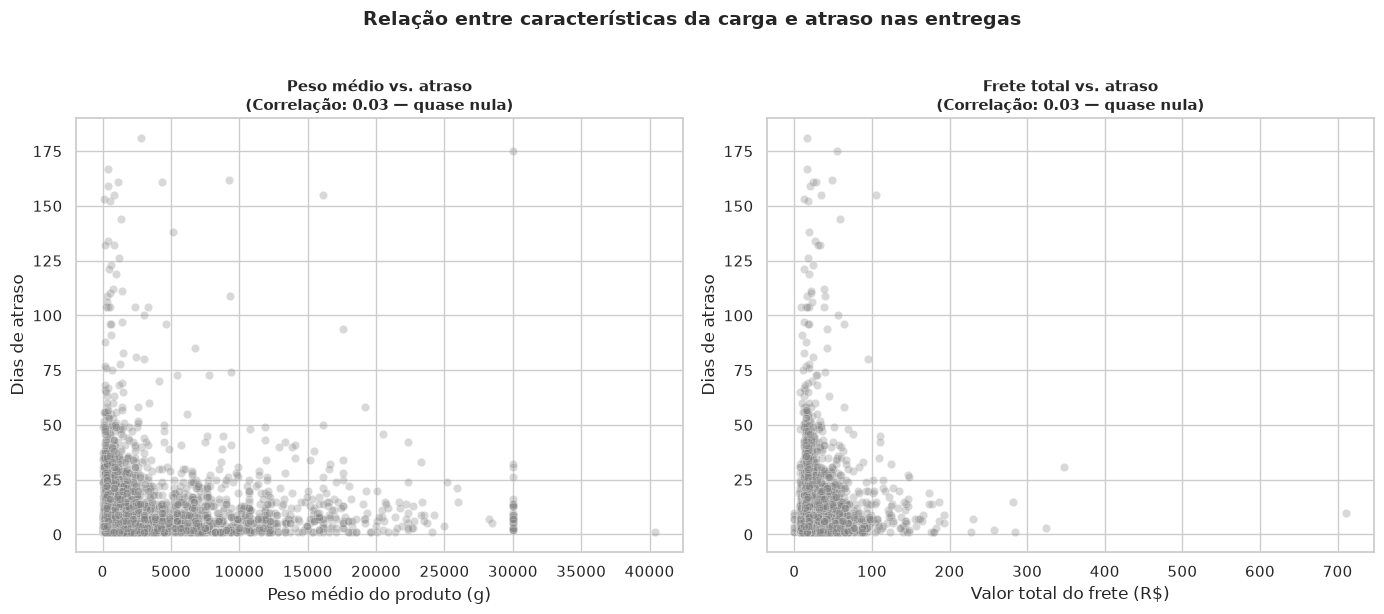

In [73]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Carregando itens e produtos
items = pd.read_csv("database/olist_order_items_dataset.csv")
products = pd.read_csv("database/olist_products_dataset.csv")

# Agregando por pedido (evita multiplicar o atraso por número de itens)
df_itens_produto = items.merge(
    products[["product_id", "product_weight_g"]], on="product_id", how="left"
)
item_por_pedido = df_itens_produto.groupby("order_id", as_index=False).agg(
    freight_value_total=("freight_value", "sum"),
    product_weight_g_medio=("product_weight_g", "mean"),
)

df_scatter = (
    df_entregues[df_entregues["foi_atraso"]][["order_id", "dias_atraso"]]
    .merge(item_por_pedido, on="order_id", how="left")
    .dropna(subset=["product_weight_g_medio", "freight_value_total"])
)

# Amostra reproduzível de até 5.000 pontos para não poluir o gráfico
df_amostra = df_scatter.sample(n=min(5000, len(df_scatter)), random_state=42)

corr_peso = df_amostra["product_weight_g_medio"].corr(df_amostra["dias_atraso"])
corr_frete = df_amostra["freight_value_total"].corr(df_amostra["dias_atraso"])

print(f"Correlação peso médio vs. atraso : {corr_peso:.2f}")
print(f"Correlação frete total vs. atraso: {corr_frete:.2f}")

fig, (ax_peso, ax_frete) = plt.subplots(1, 2, figsize=(14, 6))
sns.set_theme(style="whitegrid")

sns.scatterplot(
    data=df_amostra,
    x="product_weight_g_medio",
    y="dias_atraso",
    alpha=0.3,
    color="gray",
    ax=ax_peso,
)
ax_peso.set_title(
    f"Peso médio vs. atraso\n(Correlação: {corr_peso:.2f} — quase nula)",
    fontsize=11,
    fontweight="bold",
)
ax_peso.set_xlabel("Peso médio do produto (g)")
ax_peso.set_ylabel("Dias de atraso")

sns.scatterplot(
    data=df_amostra,
    x="freight_value_total",
    y="dias_atraso",
    alpha=0.3,
    color="gray",
    ax=ax_frete,
)
ax_frete.set_title(
    f"Frete total vs. atraso\n(Correlação: {corr_frete:.2f} — quase nula)",
    fontsize=11,
    fontweight="bold",
)
ax_frete.set_xlabel("Valor total do frete (R$)")
ax_frete.set_ylabel("Dias de atraso")

plt.suptitle(
    "Relação entre características da carga e atraso nas entregas",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

# Baixa Avaliação

* Subpergunta: O índice de satisfação de 100% (Nota 5.0) em dezembro de 2016 pode ser considerado um benchmark de sucesso para a operação de larga escala da Olist?
  * *Insight:* Não. O resultado de dezembro de 2016 é um Outlier de Contexto
. Com um volume de apenas 1 pedido (N=1), a amostra não possui representatividade para generalizar conclusões

  * *Evidência Estatística:* O desvio padrão como NaN (Not a Number) confirma matematicamente que não houve variabilidade para ser medida, já que o cálculo exige pelo menos duas observações (divisor n−1)

   * Esse dado deve ser tratado apenas como fase piloto e desconsiderado em projeções futuras

* Subpergunta: O crescimento acelerado do volume de pedidos em 2017 comprometeu a estabilidade da satisfação do cliente?
  * *Insight:* Surpreendentemente, a operação demonstrou maturidade precoce. Entre janeiro (970 pedidos) e agosto de 2017 (5.051 pedidos), o volume cresceu mais de 5 vezes, mas o Desvio Padrão reduziu de 1.27 para 1.17.

  * *Evidência dos Dados:* Uma redução no desvio padrão enquanto o volume aumenta indica que os processos estão se tornando mais previsíveis e estáveis

  * A nota média subindo de 4.19 para 4.28 prova que a Olist conseguiu escalar sem perder o controle da qualidade básica, estabelecendo o patamar de 4.28 como o KPI de "regime de cruzeiro"

* Subpergunta: Qual é a margem de incerteza real na percepção de valor do cliente após a estabilização do volume?
  * *Insight:* Embora a média seja alta (4.28), a variabilidade (1.17) indica que ainda há uma parcela significativa de clientes insatisfeitos "escondidos" atrás da média.

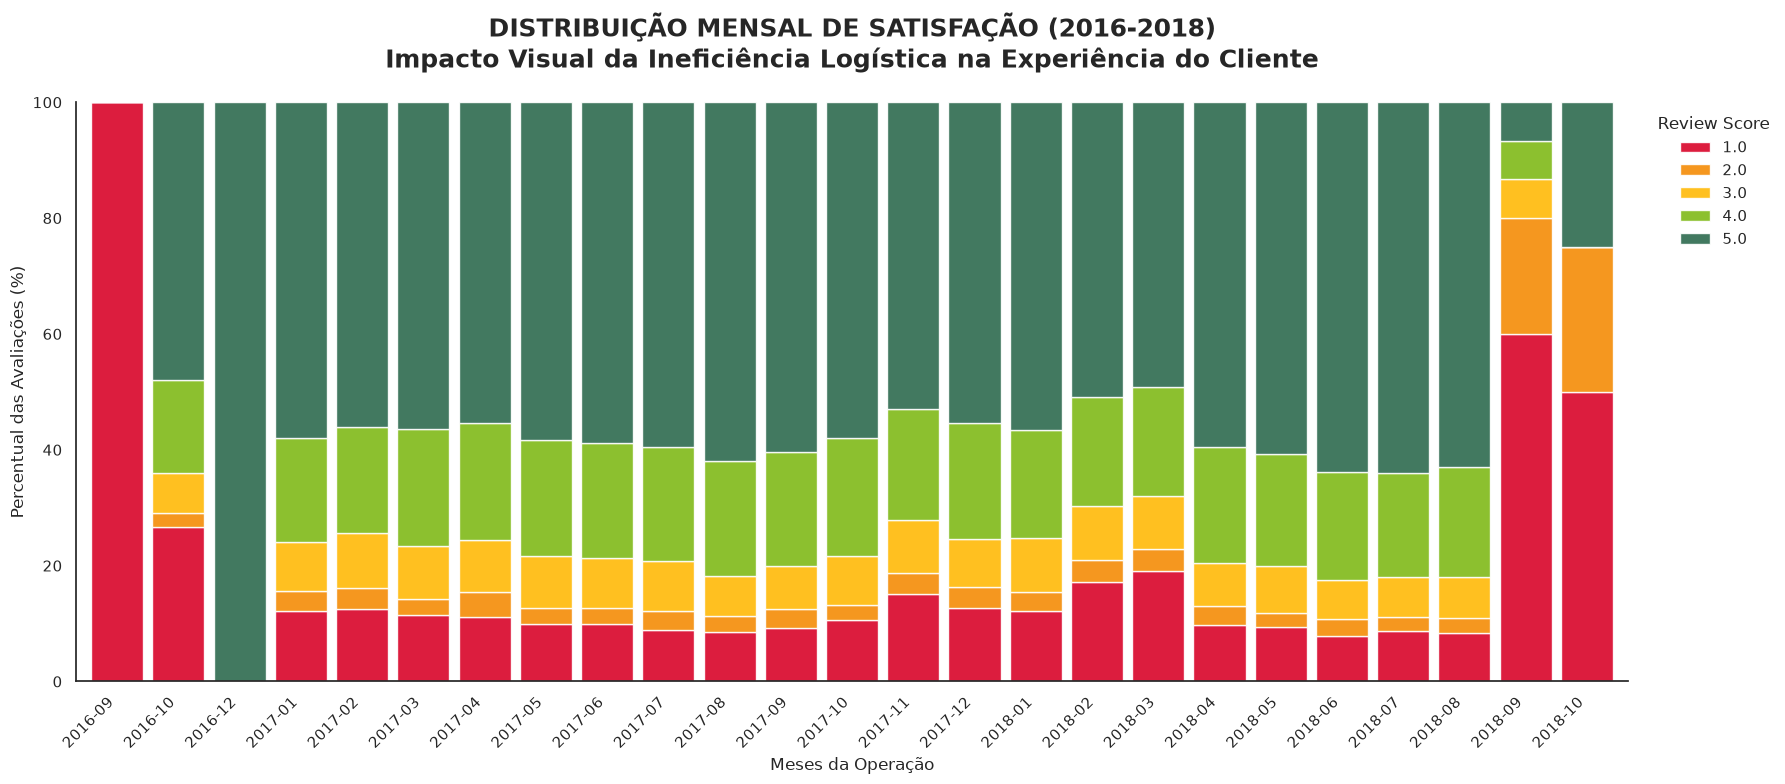

In [74]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Preparação da série temporal
# Garantindo que a data está em formato datetime e criando a coluna Ano-Mês
df_final = df_pedidos.copy()
df_final["order_purchase_timestamp"] = pd.to_datetime(
    df_final["order_purchase_timestamp"]
)
df_final["ano_mes"] = df_final["order_purchase_timestamp"].dt.to_period("M").astype(str)

# 2. Cruzamento de dados e normalização para percentual (0-100%)
# O crosstab com normalize='index' calcula a distribuição de cada nota dentro de cada mês
dist_percentual = (
    pd.crosstab(df_final["ano_mes"], df_final["review_score"], normalize="index") * 100
)

# 3. Configuração Visual (Seguindo princípios de Storytelling)
plt.figure(figsize=(18, 8))
sns.set_theme(style="white")

# Cores Semânticas: Do Vermelho (Nota 1) ao Verde (Nota 5)
cores_satisfacao = ["#D90429", "#F48C06", "#FFBA08", "#80B918", "#2D6A4F"]

# Gerando o gráfico de barras empilhadas (Stacked Bar Chart)
dist_percentual.plot(
    kind="bar",
    stacked=True,
    color=cores_satisfacao,
    ax=plt.gca(),
    width=0.85,
    alpha=0.9,
)

# 4. Elementos de Storytelling e Design
plt.title(
    "DISTRIBUIÇÃO MENSAL DE SATISFAÇÃO (2016-2018)\nImpacto Visual da Ineficiência Logística na Experiência do Cliente",
    fontsize=18,
    fontweight="bold",
    pad=25,
)
plt.xlabel("Meses da Operação", fontsize=12)
plt.ylabel("Percentual das Avaliações (%)", fontsize=12)

# Ajuste de legenda e eixos
plt.legend(
    title="Review Score", bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False
)
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 100)

# Removendo bordas desnecessárias (Design Minimalista)
sns.despine()

plt.tight_layout()
plt.show()

In [75]:
# Agrupando por mês para ver a contagem de pedidos e a nota média
validacao_volume = (
    df_final.groupby("ano_mes")
    .agg(
        {"order_id": "count", "review_score": ["mean", "std"]}  # Média e Desvio Padrão
    )
    .reset_index()
)

# Renomeando as colunas para facilitar a leitura
validacao_volume.columns = ["Mes", "Total_Pedidos", "Nota_Media", "Desvio_Padrao"]

# Filtrando o início da operação para comparação
print(validacao_volume.head(10))

       Mes  Total_Pedidos  Nota_Media  Desvio_Padrao
0  2016-09              4    1.000000       0.000000
1  2016-10            324    3.561129       1.692155
2  2016-12              1    5.000000            NaN
3  2017-01            800    4.062025       1.376040
4  2017-02           1780    4.016403       1.389288
5  2017-03           2682    4.074032       1.338894
6  2017-04           2404    4.043988       1.347809
7  2017-05           3700    4.140207       1.287354
8  2017-06           3245    4.146986       1.289044
9  2017-07           4026    4.176441       1.258093


# Clientes


*   **Subpergunta: Quem são os clientes mais afetados?**
    *   **Insight:** O atraso é um "assassino" de retenção. O risco está concentrado em **novos clientes (R\$ 824 mil)**, destruindo a possibilidade de LTV (*Lifetime Value*) logo na primeira compra.


In [76]:
# 1. Identificando frequência de compra por cliente único
frequencia_cliente = df_pedidos.groupby("customer_unique_id", as_index=False).agg(
    total_pedidos=("order_id", "nunique")
)

# 2. Unindo ao DataFrame de pedidos entregues
df_entregues = df_entregues.merge(
    frequencia_cliente, on="customer_unique_id", how="left", validate="many_to_one"
)

# 3. Criando o perfil: "Cliente recorrente" (mais de 1 pedido) vs "Novo cliente" (1 pedido)
df_entregues["perfil_cliente"] = np.where(
    df_entregues["total_pedidos"] > 1, "Cliente recorrente", "Novo cliente"
)

# 4. Analisando o risco por perfil
risco_perfil = (
    df_entregues[df_entregues["receita_em_risco_flag"]]
    .groupby("perfil_cliente", as_index=False)
    .agg(
        receita_em_risco=("payment_value", "sum"),
        pedidos_em_risco=("order_id", "nunique"),
    )
)

print("Receita em Risco por Perfil de Cliente:")
print(risco_perfil)

Receita em Risco por Perfil de Cliente:
       perfil_cliente  receita_em_risco  pedidos_em_risco
0  Cliente recorrente          29688.20               197
1        Novo cliente         691231.64              3786


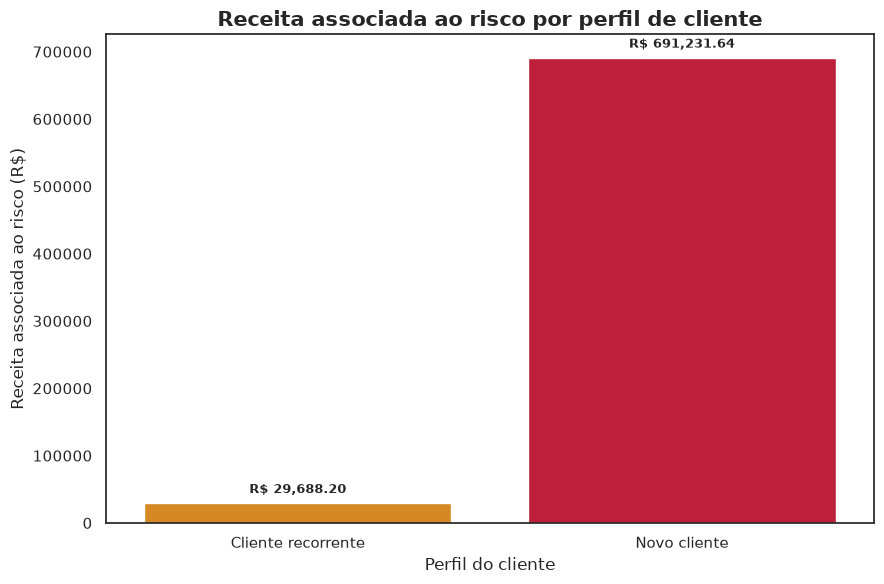

In [77]:
plt.figure(figsize=(9, 6))
ax = sns.barplot(
    data=risco_perfil,
    x="perfil_cliente",
    y="receita_em_risco",
    hue="perfil_cliente",
    palette={
        "Novo cliente": "#D90429",
        "Cliente recorrente": "#F48C06",
    },
    legend=False,
)

ax.set_title(
    "Receita associada ao risco por perfil de cliente", fontsize=15, fontweight="bold"
)
ax.set_xlabel("Perfil do cliente")
ax.set_ylabel("Receita associada ao risco (R$)")

for barra in ax.patches:
    valor = barra.get_height()
    ax.annotate(
        f"R$ {valor:,.2f}",
        (barra.get_x() + barra.get_width() / 2, valor),
        ha="center",
        va="bottom",
        xytext=(0, 5),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

* Subpergunta: O nível de satisfação na primeira compra influencia a decisão do cliente de retornar à plataforma Olist?
  * *Insight*: Sim. Atingir o nível de excelência (Nota 5 - Ótimo) é o principal motor de fidelização, resultando em uma Taxa de Retorno de 3,11%, a maior entre todas as categorias. Embora a diferença absoluta pareça pequena, proporcionalmente, um cliente "encantado" (Nota 5) tem uma propensão de retorno 12,8% maior do que um cliente que teve uma experiência apenas "boa" (Nota 4, com 2,75%).

   * *Evidência dos Dados:* A análise revela um fenômeno interessante: clientes insatisfeitos (Notas 1-3) apresentam uma taxa de retorno de 2,83%, ligeiramente superior aos que deram nota 4. Isso sugere que a Olist pode estar sendo eficaz em estratégias de "recuperação de serviço" (cupons de desconto ou reembolsos após reclamações), mas falha em converter o cliente "médio" (Nota 4) em um comprador recorrente

Taxa de Retorno por Satisfação Inicial:
  satisfacao_inicial  clientes  taxa_retorno_percentual
2        Notas 1 a 3     21890                 3.088168
0             Nota 4     18490                 2.812331
1             Nota 5     54980                 3.222990


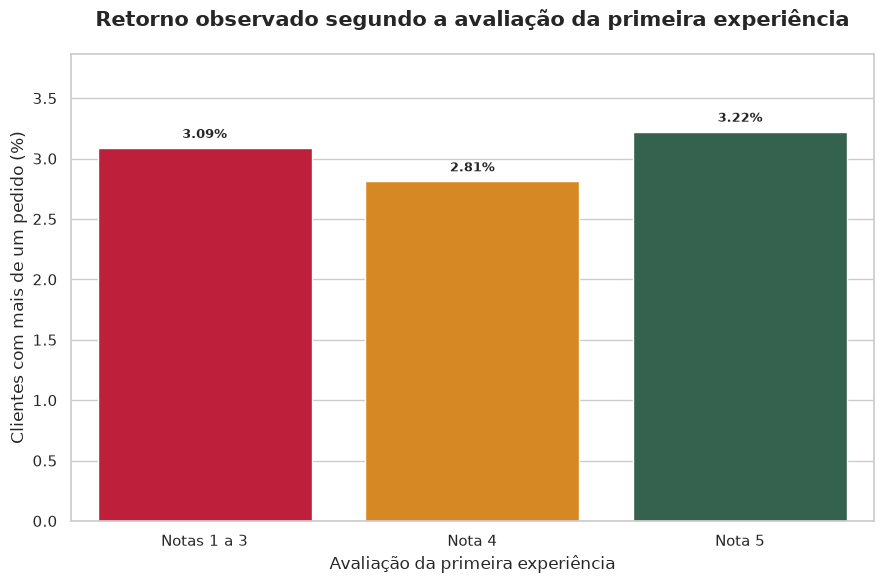

In [78]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Primeira experiência de cada cliente: ordenar por data e order_id (reproduzível)
df_cliente_ordem = df_pedidos.sort_values(
    ["customer_unique_id", "order_purchase_timestamp", "order_id"]
).copy()

primeiro_pedido = df_cliente_ordem.drop_duplicates("customer_unique_id", keep="first")[
    ["customer_unique_id", "review_score"]
]

# 2. Total de pedidos por cliente
contagem_pedidos = df_pedidos.groupby("customer_unique_id", as_index=False).agg(
    total_pedidos=("order_id", "nunique")
)

# 3. Cruzando primeira nota com comportamento de retorno
retencao = primeiro_pedido.merge(
    contagem_pedidos, on="customer_unique_id", how="left", validate="one_to_one"
)
retencao["voltou_a_comprar"] = retencao["total_pedidos"] > 1

# 4. Categorizando as notas
retencao["satisfacao_inicial"] = np.select(
    [
        retencao["review_score"] <= 3,
        retencao["review_score"] == 4,
        retencao["review_score"] == 5,
    ],
    ["Notas 1 a 3", "Nota 4", "Nota 5"],
    default="Sem avaliação",
)

# 5. Calculando a Taxa de Retorno por Categoria (excluindo sem avaliação)
taxa_retorno = (
    retencao[retencao["satisfacao_inicial"] != "Sem avaliação"]
    .groupby("satisfacao_inicial", as_index=False)
    .agg(
        clientes=("customer_unique_id", "nunique"),
        taxa_retorno=("voltou_a_comprar", "mean"),
    )
)
taxa_retorno["taxa_retorno_percentual"] = taxa_retorno["taxa_retorno"] * 100

ordem_retorno = {"Notas 1 a 3": 0, "Nota 4": 1, "Nota 5": 2}
taxa_retorno["ordem"] = taxa_retorno["satisfacao_inicial"].map(ordem_retorno)
taxa_retorno = taxa_retorno.sort_values("ordem")

print("Taxa de Retorno por Satisfação Inicial:")
print(taxa_retorno[["satisfacao_inicial", "clientes", "taxa_retorno_percentual"]])

# --- Gráfico ---
plt.figure(figsize=(9, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=taxa_retorno,
    x="satisfacao_inicial",
    y="taxa_retorno_percentual",
    hue="satisfacao_inicial",
    palette=["#D90429", "#F48C06", "#2D6A4F"],
    legend=False,
)

ax.set_title(
    "Retorno observado segundo a avaliação da primeira experiência",
    fontsize=15,
    fontweight="bold",
    pad=20,
)
ax.set_ylabel("Clientes com mais de um pedido (%)", fontsize=12)
ax.set_xlabel("Avaliação da primeira experiência", fontsize=12)
ax.set_ylim(0, taxa_retorno["taxa_retorno_percentual"].max() * 1.2)

for barra in ax.patches:
    valor = barra.get_height()
    ax.annotate(
        f"{valor:.2f}%",
        (barra.get_x() + barra.get_width() / 2, valor),
        ha="center",
        va="bottom",
        xytext=(0, 5),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
    )

plt.tight_layout()
plt.show()